# Compare two root files describing the jet constituent observables used for tagging

You can retrieve the jet constituent observables to a root file using the steering file `writeJetConstObs.py`. You can find out how to submit large jobs on condor in the `/extras/submit_to_condor` folder. 
 

HERE: compare CLD_v5 and CLD_v7

In [2]:
import uproot 
import numpy as np
import matplotlib.pyplot as plt

from helper_jetobs import *

%load_ext autoreload
%autoreload 2

In [57]:
# change the paths here to use your own files 

base_path_CLD_v7 = "/eos/experiment/fcc/ee/datasets/CLD_fullsim_tagging_from_key4hep/CLD_v7/"

path_1 = base_path_CLD_v7 + "Hbb_0.root" #Hxx_0.root # full sim from key4hep
path_2 = "/eos/experiment/fcc/ee/datasets/CLD_fullsim_tagging_input/Hbb_0.root" # Htautau_1200.root" #Hdd_400.root "#Huu_200.root "#Hcc_600.root" #Hss_800.root" #Hbb_0.root # full sim from my own python script

In [58]:
file_1 = uproot.open(path_1)
tree_1 = file_1["JetConstituentObservables;1"]

file_2 = uproot.open(path_2)
tree_2 = file_2["tree;1"]

# adapt the size of the data you want to load here
df_1 = tree_1.arrays(library="np", entry_start=0, entry_stop=3000) 
df_2 = tree_2.arrays(library="np", entry_start=0, entry_stop=3000)

These are the keys from key4hep root file: 

In [59]:
df_1.keys()

dict_keys(['pfcand_erel_log', 'pfcand_thetarel', 'pfcand_phirel', 'pfcand_e', 'pfcand_p', 'pfcand_type', 'pfcand_charge', 'pfcand_isEl', 'pfcand_isMu', 'pfcand_isGamma', 'pfcand_isChargedHad', 'pfcand_isNeutralHad', 'pfcand_dndx', 'pfcand_tof', 'pfcand_cov_omegaomega', 'pfcand_cov_tanLambdatanLambda', 'pfcand_cov_phiphi', 'pfcand_cov_d0d0', 'pfcand_cov_z0z0', 'pfcand_cov_d0z0', 'pfcand_cov_phid0', 'pfcand_cov_tanLambdaz0', 'pfcand_cov_d0omega', 'pfcand_cov_d0tanLambda', 'pfcand_cov_phiomega', 'pfcand_cov_phiz0', 'pfcand_cov_phitanLambda', 'pfcand_cov_omegaz0', 'pfcand_cov_omegatanLambda', 'pfcand_d0', 'pfcand_z0', 'pfcand_Sip2dVal', 'pfcand_Sip2dSig', 'pfcand_Sip3dVal', 'pfcand_Sip3dSig', 'pfcand_JetDistVal', 'pfcand_JetDistSig', 'jet_PV_x', 'jet_PV_y', 'jet_PV_z'])

(I need to convert my old keys into the new convention, ignore this part)

In [60]:
key_map = { 
    "pfcand_erel_log": "pfcand_erel_log",
    "pfcand_thetarel": "pfcand_thetarel",
    "pfcand_phirel": "pfcand_phirel",
    "pfcand_dptdpt": "pfcand_cov_omegaomega",
    "pfcand_detadeta": "pfcand_cov_tanLambdatanLambda",
    "pfcand_dphidphi": "pfcand_cov_phiphi",
    "pfcand_dxydxy": "pfcand_cov_d0d0",
    "pfcand_dzdz": "pfcand_cov_z0z0",
    "pfcand_dxydz": "pfcand_cov_d0z0",
    "pfcand_dphidxy": "pfcand_cov_phid0",
    "pfcand_dlambdadz": "pfcand_cov_tanLambdaz0",
    "pfcand_dxyc": "pfcand_cov_d0omega",
    "pfcand_dxyctgtheta": "pfcand_cov_d0tanLambda",
    "pfcand_phic": "pfcand_cov_phiomega",
    "pfcand_phidz": "pfcand_cov_phiz0",
    "pfcand_phictgtheta": "pfcand_cov_phitanLambda",
    "pfcand_cdz": "pfcand_cov_omegaz0",
    "pfcand_cctgtheta": "pfcand_cov_omegatanLambda",
    "pfcand_dxy": "pfcand_d0",
    "pfcand_dz": "pfcand_z0",
    "pfcand_btagSip2dVal": "pfcand_Sip2dVal",
    "pfcand_btagSip2dSig": "pfcand_Sip2dSig",
    "pfcand_btagSip3dVal": "pfcand_Sip3dVal",
    "pfcand_btagSip3dSig": "pfcand_Sip3dSig",
    "pfcand_btagJetDistVal": "pfcand_JetDistVal",
    "pfcand_btagJetDistSig": "pfcand_JetDistSig",
    "pfcand_type": "pfcand_type",
    "pfcand_charge": "pfcand_charge",
    "pfcand_isEl": "pfcand_isEl",
    "pfcand_isMu": "pfcand_isMu",
    "pfcand_isGamma": "pfcand_isGamma",
    "pfcand_isChargedHad": "pfcand_isChargedHad",
    "pfcand_isNeutralHad": "pfcand_isNeutralHad",
    "pfcand_dndx": "pfcand_dndx",
    "pfcand_mtof": "pfcand_tof",
    "pfcand_e": "pfcand_e",
    "pfcand_p": "pfcand_p",
}


In [61]:
df_2 = {key_map.get(k): v for k, v in df_2.items() if key_map.get(k) is not None}

Plot variables:

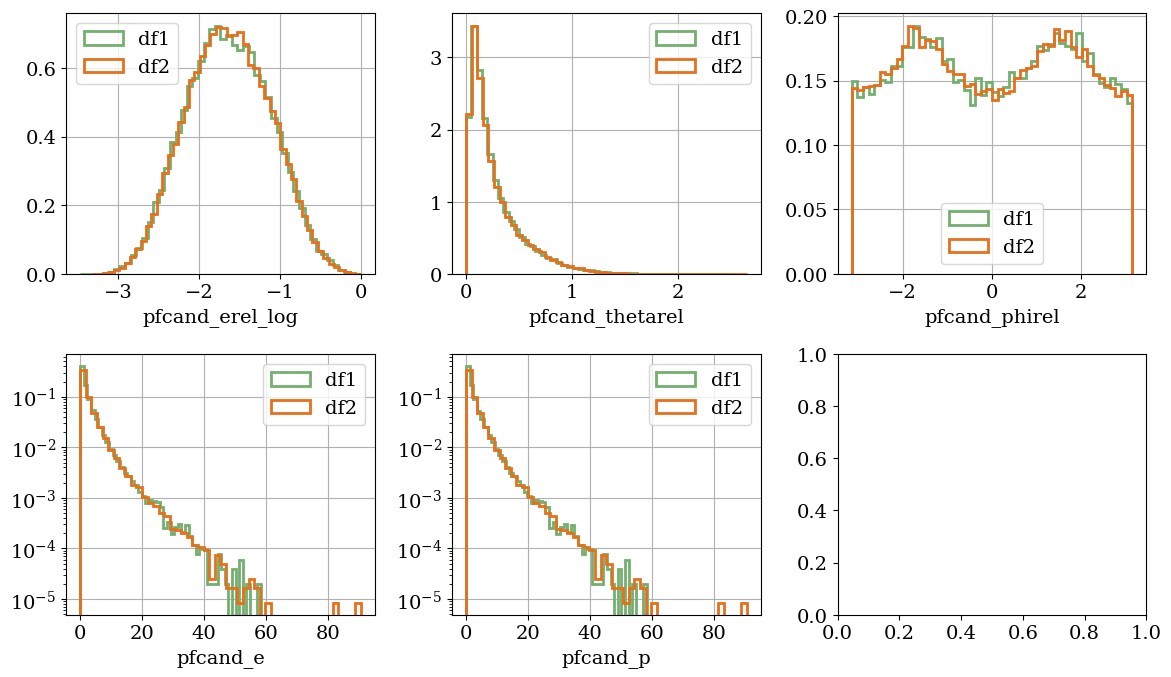

In [62]:
plot_kinematics(df_1, df_2)

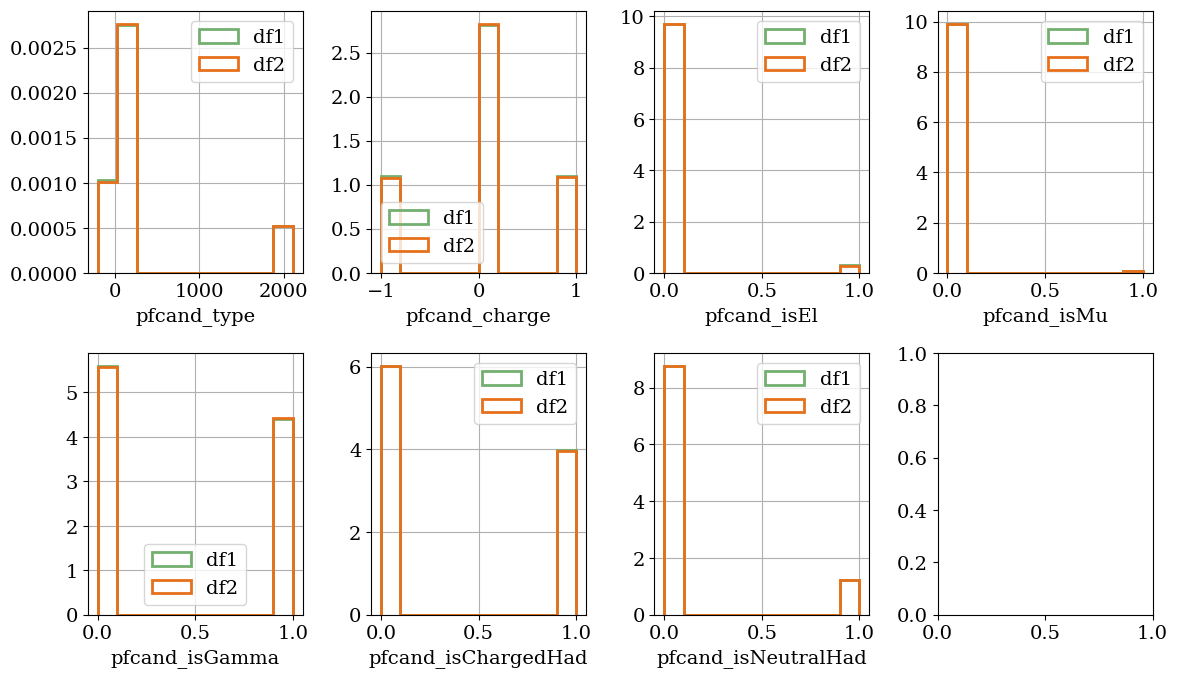

In [63]:
plot_pidflags(df_1, df_2)

We need to select the charged particles and find the highest energetic ones:

In [64]:
# these are lists because there might not always be 3 charged particles
index_charged_3E_1 = get_value_highest_energy_particle(df_1)
index_charged_3E_2 = get_value_highest_energy_particle(df_2)

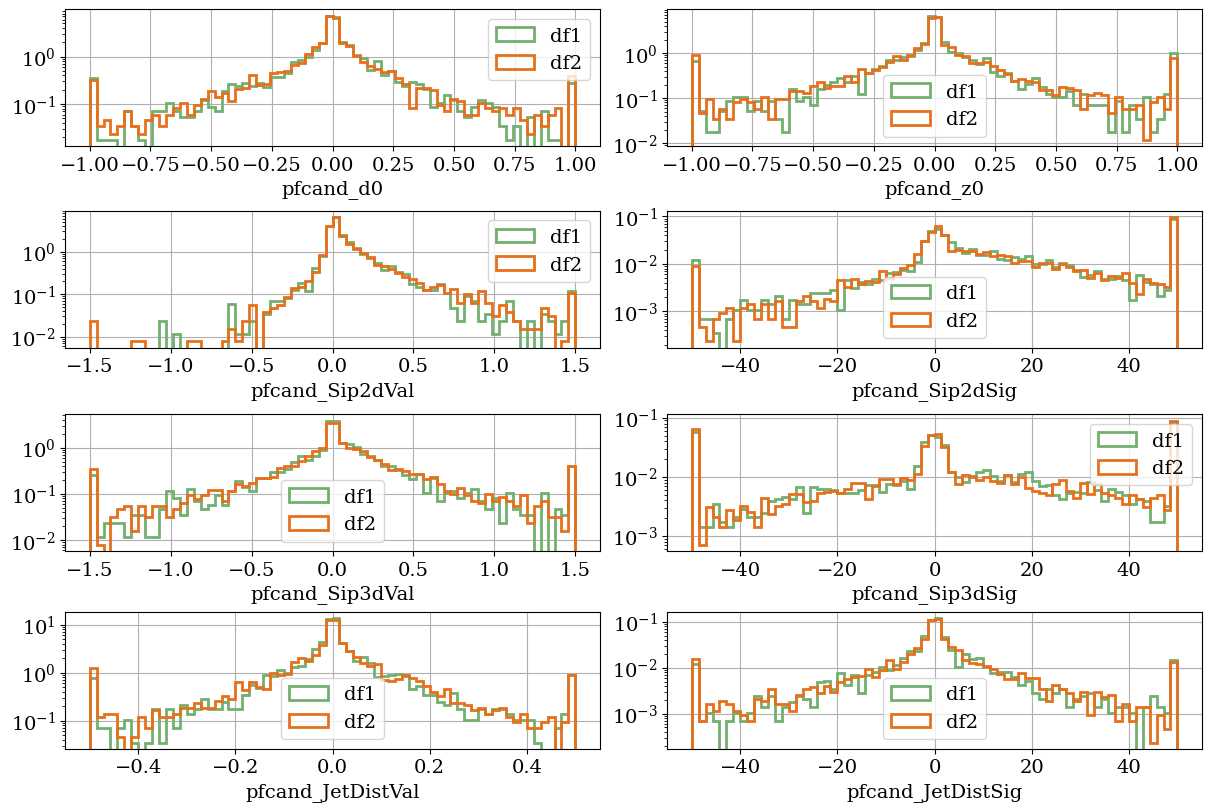

In [65]:
plot_IP(df_1, df_2, index_charged_3E_1, index_charged_3E_2)

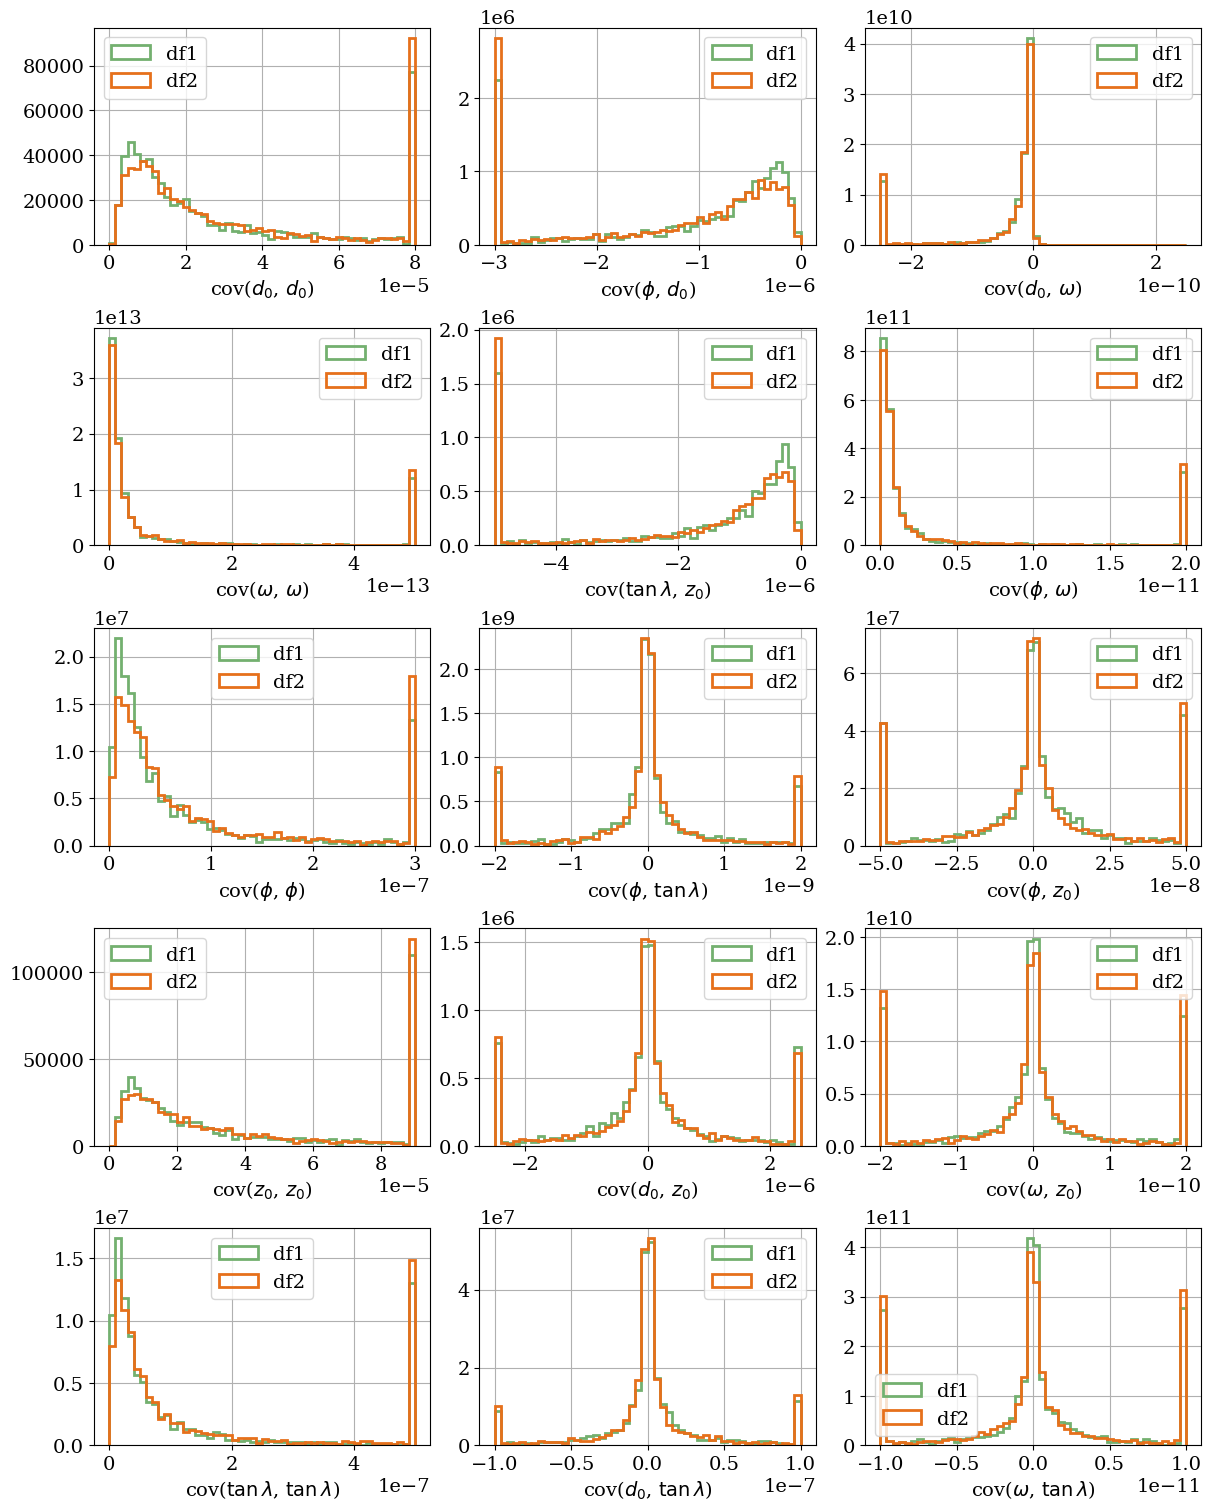

In [66]:
plot_cov_matrix(df_1, df_2, index_charged_3E_1, index_charged_3E_2)

NO INPUT to the network, but check primary verticies:

In [67]:
df_1.keys()

dict_keys(['pfcand_erel_log', 'pfcand_thetarel', 'pfcand_phirel', 'pfcand_e', 'pfcand_p', 'pfcand_type', 'pfcand_charge', 'pfcand_isEl', 'pfcand_isMu', 'pfcand_isGamma', 'pfcand_isChargedHad', 'pfcand_isNeutralHad', 'pfcand_dndx', 'pfcand_tof', 'pfcand_cov_omegaomega', 'pfcand_cov_tanLambdatanLambda', 'pfcand_cov_phiphi', 'pfcand_cov_d0d0', 'pfcand_cov_z0z0', 'pfcand_cov_d0z0', 'pfcand_cov_phid0', 'pfcand_cov_tanLambdaz0', 'pfcand_cov_d0omega', 'pfcand_cov_d0tanLambda', 'pfcand_cov_phiomega', 'pfcand_cov_phiz0', 'pfcand_cov_phitanLambda', 'pfcand_cov_omegaz0', 'pfcand_cov_omegatanLambda', 'pfcand_d0', 'pfcand_z0', 'pfcand_Sip2dVal', 'pfcand_Sip2dSig', 'pfcand_Sip3dVal', 'pfcand_Sip3dSig', 'pfcand_JetDistVal', 'pfcand_JetDistSig', 'jet_PV_x', 'jet_PV_y', 'jet_PV_z'])

In [68]:

def plot_PV(df1, df2, l1='df1', l2='df2', bins=50):
    keys = ['jet_PV_x', 'jet_PV_y', 'jet_PV_z']

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    units = ["$\mu$m", "nm", "mm"]
    r = {
        "jet_PV_x": (-30, 30),
        "jet_PV_y": (-70, 70),
        "jet_PV_z": (-2, 2),
    }
    multipliers = {
        "jet_PV_x": 1e3,
        "jet_PV_y": 1e6,
        "jet_PV_z": 1,
    }
    xlabels = [r"$x$ ($\mu$m)", "$y$ (nm)", "$z$ (mm)"]

    for i, key in enumerate(keys):
        data1 = df1[key]* multipliers[key] 
        rms1 = np.sqrt(np.mean(data1**2))
        #data2 = df2[key]* multipliers[key] 
        #rms2 = np.sqrt(np.mean(data2**2))
        # overflow bins
        d1 = np.clip(data1, r[key][0], r[key][1])
        #d2 = np.clip(data2, r[key][0], r[key][1])

        # plot histograms
        axs[i].hist(d1, bins=bins, range=r[key], histtype="step", label="{} \nRMS={:.2f} {}".format(l1, rms1, units[i]), density=True, linewidth=2)
        #axs[i].hist(d2, bins=bins, range=r[key], histtype="step", label="{} \nRMS={:.2f} {}".format(l2, rms1, units[i]), density=True, linewidth=2)

        axs[i].set_xlabel(xlabels[i])
        axs[i].grid()
        axs[i].legend()

    plt.show()


        

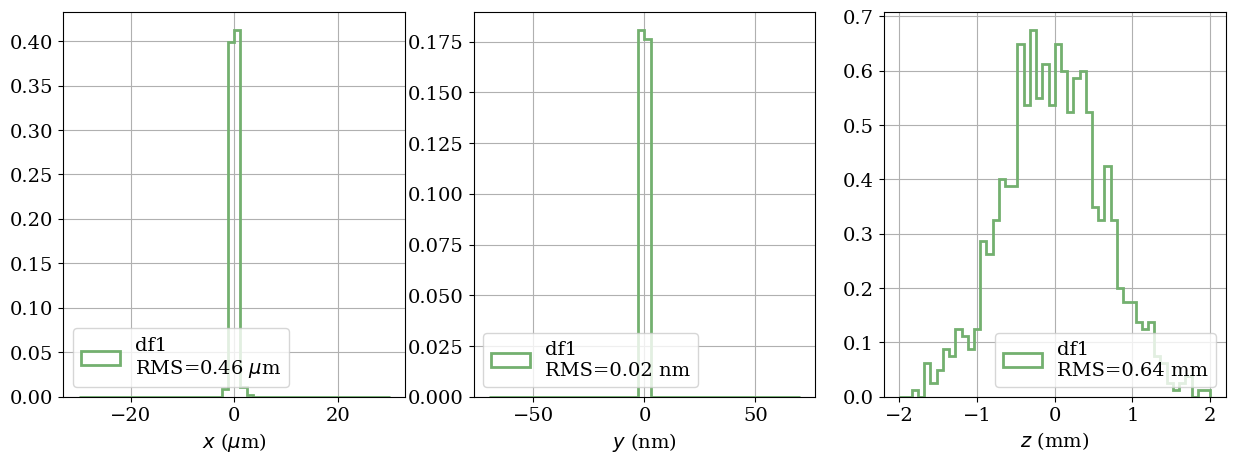

In [69]:
plot_PV(df_1, df_2, l1='df1', l2='df2', bins=50)

# Check PV for all flavors

In [26]:
path_Huu = base_path_CLD_v7 + "Huu_0.root"  
path_Hdd = base_path_CLD_v7 + "Hdd_0.root"  
path_Hss = base_path_CLD_v7 + "Hss_0.root"  
path_Hbb = base_path_CLD_v7 + "Hbb_0.root"  
path_Hcc = base_path_CLD_v7 + "Hcc_0.root"  
path_Hgg = base_path_CLD_v7 + "Hgg_0.root"  
path_Htautau = base_path_CLD_v7 + "Htautau_0.root"  

In [27]:
def load_data(file_name, stop=3000, key='JetConstituentObservables;1'):
    file = uproot.open(file_name)
    tree = file[key]
    data = tree.arrays(library="np", entry_start=0, entry_stop=stop)
    return data

In [28]:
dic = {
    'Hgg': load_data(path_Hgg),
    'Huu': load_data(path_Huu),
    'Hdd': load_data(path_Hdd),
    'Hss': load_data(path_Hss),
    'Hcc': load_data(path_Hcc),
    'Hbb': load_data(path_Hbb),
    'Htautau': load_data(path_Htautau)
}

In [42]:

def plot_PV(dic, bins=50):
    keys = ['jet_PV_x', 'jet_PV_y', 'jet_PV_z']

    fig, axs = plt.subplots(1, 3, figsize=(20, 7))
    units = ["$\mu$m", "nm", "mm"]
    r = {
        "jet_PV_x": (-3, 3), # (-30, 30),
        "jet_PV_y": (-0.2, 0.2), # (-70, 70),
        "jet_PV_z": (-2, 2),
    }
    multipliers = {
        "jet_PV_x": 1e3,
        "jet_PV_y": 1e6,
        "jet_PV_z": 1,
    }
    xlabels = [r"$x$ ($\mu$m)", "$y$ (nm)", "$z$ (mm)"]

    for j, flavor in enumerate(dic.keys()):
        for i, key in enumerate(keys):
            data = dic[flavor][key] * multipliers[key]
            rms = np.sqrt(np.mean(data**2))
            # overflow bins
            d = np.clip(data, r[key][0], r[key][1])

            # plot histograms
            axs[i].hist(d, bins=bins, range=r[key], histtype="step", label="{} (RMS={:.2f} {})".format(flavor, rms, units[i]), density=True, linewidth=2)

            axs[i].set_xlabel(xlabels[i])
            axs[i].grid()
            axs[i].legend() #loc="lower left")
            axs[i].set_yscale("log")

    plt.show()


        

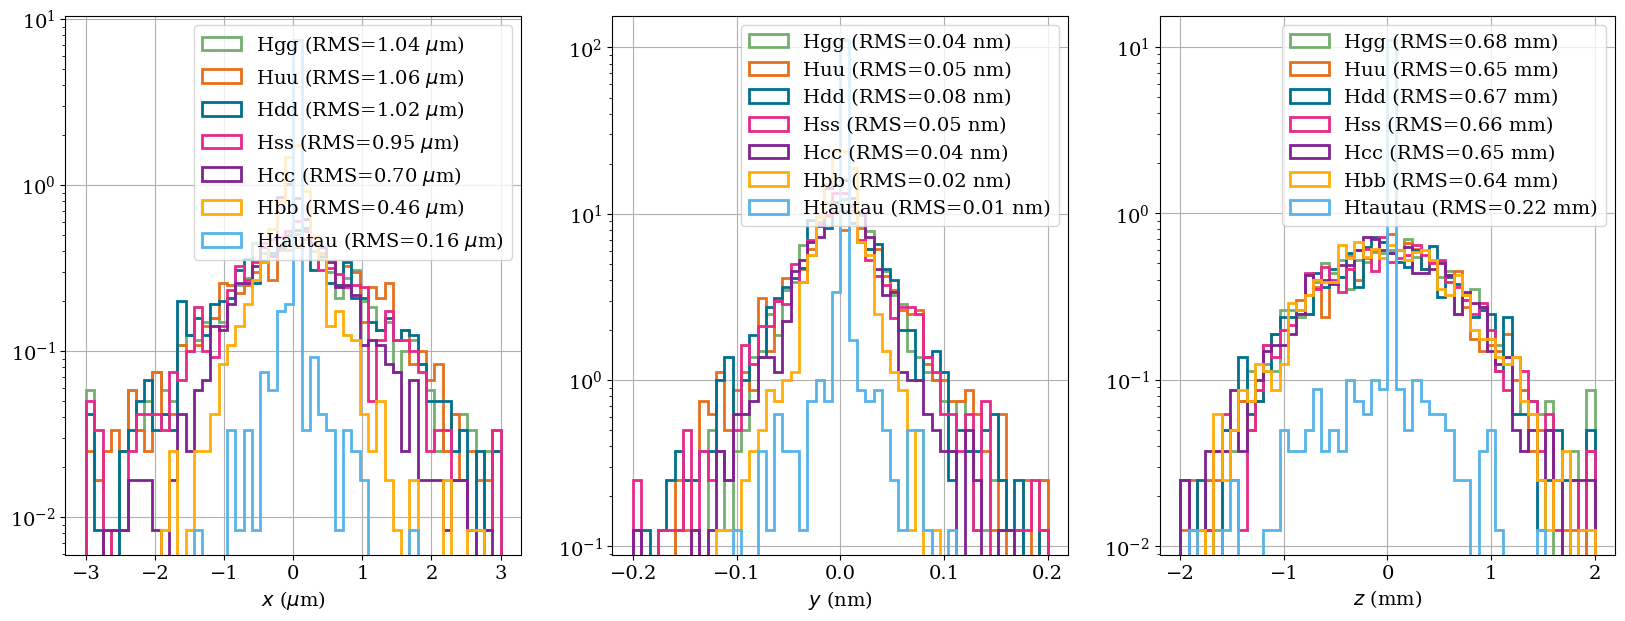

In [43]:
plot_PV(dic)